<a href="https://colab.research.google.com/github/ParthPanchall/Pneumonia-Detection/blob/main/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `Step 1`: Importing the dataset

In [ ]:
# Installing kaggle
!pip install -q kaggle

In [ ]:
# To upload kaggle json file from the local systems
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vinitkhedu","key":"048a9c2f7dd036b48fbf7807cdd1ba5a"}'}

In [ ]:
# Create a kaggle directory
!mkdir ~/.kaggle

In [ ]:
# Copy the kaggle.json to folder created 
!cp kaggle.json ~/.kaggle/

In [ ]:

# Permission for the json to act
!chmod 600 ~/.kaggle/kaggle.json 

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

100% 2.29G/2.29G [01:03<00:00, 41.4MB/s]
100% 2.29G/2.29G [01:03<00:00, 38.7MB/s]


# `Step 2`: Unzip the dataset and make directories 

In [ ]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
# Import the helper function and  get the functions needed that we are going to need in this notebook
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2023-03-30 06:19:19--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2023-03-30 06:19:19 (86.6 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
from helper_functions import walk_through_dir, plot_loss_curves

In [ ]:
import shutil
# shutil.rmtree("/content/chest_xray/__MACOSX")
shutil.rmtree("/content/chest_xray/chest_xray")

In [ ]:
walk_through_dir("/content/chest_xray")

There are 4 directories and 0 images in '/content/chest_xray'.
There are 2 directories and 0 images in '/content/chest_xray/test'.
There are 0 directories and 234 images in '/content/chest_xray/test/NORMAL'.
There are 0 directories and 390 images in '/content/chest_xray/test/PNEUMONIA'.
There are 1 directories and 1 images in '/content/chest_xray/__MACOSX'.
There are 3 directories and 3 images in '/content/chest_xray/__MACOSX/chest_xray'.
There are 2 directories and 3 images in '/content/chest_xray/__MACOSX/chest_xray/test'.
There are 0 directories and 234 images in '/content/chest_xray/__MACOSX/chest_xray/test/NORMAL'.
There are 0 directories and 390 images in '/content/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA'.
There are 2 directories and 1 images in '/content/chest_xray/__MACOSX/chest_xray/val'.
There are 0 directories and 9 images in '/content/chest_xray/__MACOSX/chest_xray/val/NORMAL'.
There are 0 directories and 9 images in '/content/chest_xray/__MACOSX/chest_xray/val/PNEUMO

In [ ]:
# Visualize the images 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def view_random_images(target_dir, target_class):
  # Setup the target directory 
  target_folder = target_dir + target_class

  # Get the random image path
  rand_img = random.sample(os.listdir(target_folder), 1)

  # Read the image and plot
  img = mpimg.imread(target_folder + "/" + rand_img[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis(False);

  print(f"Image shape :{img.shape}")

  return img

Image shape :(317, 640, 3)


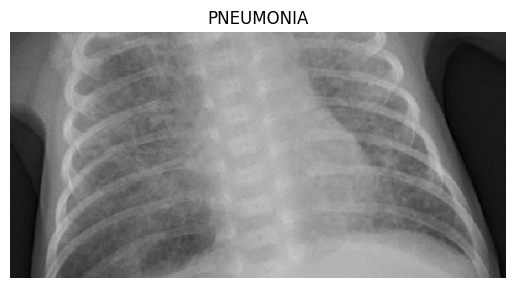

In [ ]:
img = view_random_images(target_dir="/content/chest_xray/train/",
                         target_class="PNEUMONIA")

Image shape :(2237, 2260)


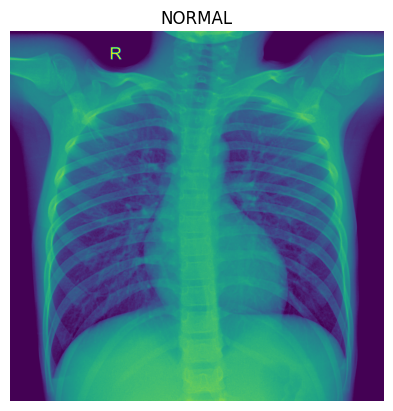

In [ ]:
img = view_random_images(target_dir="/content/chest_xray/train/",
                         target_class="NORMAL")

# Preparing the data for modelling


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# 1. Preprocessing the data (getting the values between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# 2. Setting and getting the path of our directories 
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
val_dir = "/content/chest_xray/val"

# 3. Importing the data from the directories and turn it into the batches
print("Train Data")
train_data = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                 batch_size=32,
                                                                 image_size=(224, 224),
                                                                 label_mode="binary",
                                                                 seed=42)

print("Test Data")
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                batch_size=32,
                                                                image_size=(224,224),
                                                                label_mode="binary",
                                                                seed=42)

print("Val Data")
val_data = tf.keras.preprocessing.image_dataset_from_directory(directory=val_dir,
                                                                batch_size=32,
                                                                image_size=(224,224),
                                                                label_mode="binary",
                                                                seed=42)



Train Data
Found 5216 files belonging to 2 classes.
Test Data
Found 624 files belonging to 2 classes.
Val Data
Found 16 files belonging to 2 classes.


In [ ]:
train_data.class_names

['NORMAL', 'PNEUMONIA']

# `Step 3`: Modelling


In [ ]:
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Activation, Flatten
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

# 1. Create a model

baseline_model = Sequential([
    Conv2D(filters=32,
           kernel_size=3,
           input_shape=(224, 224, 3),
           activation="relu"),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])
# 2. Compile the model
baseline_model.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# 3. Fit the model
hist_baseline = baseline_model.fit(train_data,
                                   epochs=5,
                                   steps_per_epoch=len(train_data),
                                   validation_data=test_data,
                                   validation_steps=len(test_data))

Epoch 1/5


KeyboardInterrupt: ignored

In [ ]:
# Looks like the model is overfitting 

model_0 = Sequential([
    Conv2D(filters=32,
           kernel_size=3,
           input_shape=(224, 224, 3),
           activation="relu"),
    MaxPool2D(strides=2),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(128, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile the model
model_0.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Fit the model
hist_0 = model_0.fit(train_data,
                     epochs=5,
                     steps_per_epoch=len(train_data),
                     validation_data=test_data,
                     validation_steps=len(test_data))

Epoch 1/5
163/163 [==============================] - 34s 189ms/step - loss: 6.1057 - accuracy: 0.8840 - val_loss: 0.5357 - val_accuracy: 0.7997
Epoch 2/5
163/163 [==============================] - 32s 187ms/step - loss: 0.1043 - accuracy: 0.9643 - val_loss: 1.5234 - val_accuracy: 0.6891
Epoch 3/5
163/163 [==============================] - 32s 188ms/step - loss: 0.0683 - accuracy: 0.9739 - val_loss: 1.0552 - val_accuracy: 0.7516
Epoch 4/5
163/163 [==============================] - 33s 192ms/step - loss: 0.0463 - accuracy: 0.9831 - val_loss: 1.2633 - val_accuracy: 0.7516
Epoch 5/5
163/163 [==============================] - 31s 183ms/step - loss: 0.0435 - accuracy: 0.9841 - val_loss: 1.4775 - val_accuracy: 0.7420


In [ ]:
# Trying data augmentation to avoid overfitting
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen_aug = ImageDataGenerator(rescale = 1/255,
        shear_range=10,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.5,2.0],
        width_shift_range = 0.2,
        rotation_range=20,
        fill_mode = 'nearest')

test_datagen_aug = ImageDataGenerator(rescale=1/255.)

In [ ]:
train_data_aug = train_datagen_aug.flow_from_directory(train_dir,
                                                       target_size=(224, 224),
                                                       batch_size=32,
                                                       class_mode="binary",
                                                       seed=42)


test_data_aug = test_datagen_aug.flow_from_directory(test_dir,
                                                     target_size=(224, 224),
                                                     batch_size=32,
                                                     class_mode="binary",
                                                     seed=42)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model_1 = tf.keras.models.clone_model(model_0)

# Compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Fit the model
hist_1 = model_1.fit(train_data_aug,
                     epochs=5,
                     steps_per_epoch=len(train_data_aug),
                     validation_data=test_data_aug,
                     validation_steps=len(test_data_aug))

Epoch 1/5
163/163 [==============================] - 124s 750ms/step - loss: 0.4417 - accuracy: 0.7788 - val_loss: 0.4343 - val_accuracy: 0.7885
Epoch 2/5
163/163 [==============================] - 121s 745ms/step - loss: 0.3475 - accuracy: 0.8447 - val_loss: 0.4290 - val_accuracy: 0.7949
Epoch 3/5
163/163 [==============================] - 123s 756ms/step - loss: 0.3114 - accuracy: 0.8641 - val_loss: 0.3998 - val_accuracy: 0.8157
Epoch 4/5
163/163 [==============================] - 124s 761ms/step - loss: 0.2797 - accuracy: 0.8735 - val_loss: 0.3601 - val_accuracy: 0.8494
Epoch 5/5
163/163 [==============================] - 123s 757ms/step - loss: 0.2461 - accuracy: 0.8905 - val_loss: 0.6260 - val_accuracy: 0.7099


In [ ]:
# Evaluate the model
model_1.evaluate(test_data_aug)

20/20 [==============================] - 12s 570ms/step - loss: 0.6269 - accuracy: 0.7067


[0.6269363760948181, 0.7067307829856873]

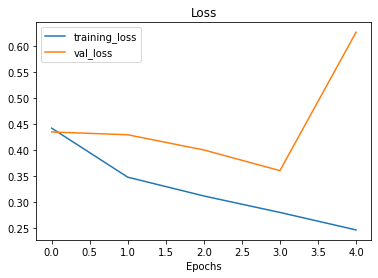

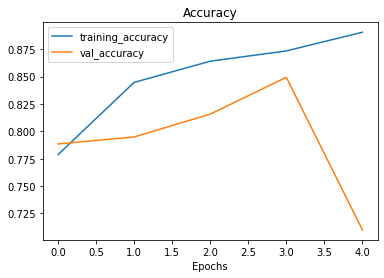

In [ ]:
plot_loss_curves(hist_1)

In [ ]:
class_names = train_data.class_names
class_names

['NORMAL', 'PNEUMONIA']

# `Transfer Learning`

In [ ]:
# 1. Create base model with tf.keras.application
base_model = tf.keras.applications.EfficientNetB0(include_top=False)

# 2. Freeze the base model
base_model.trainable = False

# 3. Create inputs into the base model
inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")

# 4. Pass the inputs to the base model
x = base_model(inputs)

# 5. Average pool the outputs of the base model
x = tf.keras.layers.GlobalAveragePooling2D(name="GAPL")(x)

# 6. Create the output activation layer
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output_layer")(x)

# 7. Combine the inputs with the outputs into the model
model_2 = tf.keras.Model(inputs, outputs)



16705208/16705208 [==============================] - 0s 0us/step


In [ ]:
# Compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Fit the model
hist_2 =  model_2.fit(train_data,
                     epochs=5,
                     steps_per_epoch=len(train_data),
                     validation_data=test_data,
                     validation_steps= int(0.25 *len(test_data)))

Epoch 1/5
163/163 [==============================] - 39s 195ms/step - loss: 0.2836 - accuracy: 0.8802 - val_loss: 0.3977 - val_accuracy: 0.7937
Epoch 2/5
163/163 [==============================] - 30s 177ms/step - loss: 0.1769 - accuracy: 0.9306 - val_loss: 0.4559 - val_accuracy: 0.7875
Epoch 3/5
163/163 [==============================] - 31s 184ms/step - loss: 0.1490 - accuracy: 0.9438 - val_loss: 0.4585 - val_accuracy: 0.7688
Epoch 4/5
163/163 [==============================] - 30s 177ms/step - loss: 0.1315 - accuracy: 0.9480 - val_loss: 0.5663 - val_accuracy: 0.7688
Epoch 5/5
163/163 [==============================] - 31s 183ms/step - loss: 0.1261 - accuracy: 0.9523 - val_loss: 0.4549 - val_accuracy: 0.7875


In [ ]:
vgg_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top = False,
#     input_shape = (224,224,3)
)

for layer in vgg_model.layers:
    layer.trainable=False
    
x = vgg_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model = tf.keras.Model(inputs=vgg_model.input, outputs=predictions)

# to avoid overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=7)
lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=5)

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])


80134624/80134624 [==============================] - 3s 0us/step


In [ ]:
history = model.fit(train_data_aug,epochs=30, 
                    validation_data=test_data_aug,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/30
100/100 [==============================] - 101s 890ms/step - loss: 0.5123 - accuracy: 0.7509 - val_loss: 0.5510 - val_accuracy: 0.7660 - lr: 0.0010
Epoch 2/30
100/100 [==============================] - 86s 865ms/step - loss: 0.4346 - accuracy: 0.8012 - val_loss: 0.5030 - val_accuracy: 0.7372 - lr: 0.0010
Epoch 3/30
100/100 [==============================] - 87s 863ms/step - loss: 0.4091 - accuracy: 0.8097 - val_loss: 0.4788 - val_accuracy: 0.7628 - lr: 0.0010
Epoch 4/30
100/100 [==============================] - 85s 848ms/step - loss: 0.3980 - accuracy: 0.8241 - val_loss: 0.4945 - val_accuracy: 0.7260 - lr: 0.0010
Epoch 5/30
100/100 [==============================] - 86s 858ms/step - loss: 0.3843 - accuracy: 0.8259 - val_loss: 0.4693 - val_accuracy: 0.7660 - lr: 0.0010
Epoch 6/30
100/100 [==============================] - 86s 863ms/step - loss: 0.3437 - accuracy: 0.8416 - val_loss: 0.4559 - val_accuracy: 0.7708 - lr: 0.0010
Epoch 7/30
100/100 [==============================]

## Adding data augmentation right into the model
To add data augmentation right into our models, we can use the layers inside:
* `tf.keras. layers.experimental.preprocessing()`

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

# Create data augmentation stage with horizontal flipping,rotations,zooms,heigh,width
data_augmentation = keras.Sequential([
    preprocessing.RandomFlip("horizontal"),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomZoom(0.2),
    preprocessing.RandomWidth(0.2),
    preprocessing.RandomHeight(0.2),
    # preprocessing.Rescale(1./255) # keep for models like ResNet50V2 but EfficientNet does not need
],name="data_augmentation")

In [ ]:
# Create a base model with tf.keras application
base_model = tf.keras.applications.EfficientNetB7(input_shape = (224,224,3),include_top = False,weights='imagenet');
 # Freezethe base model
base_model.trainable = False;

#Create inputs to base_model
inputs = tf.keras.layers.Input(shape=(224,224,3),name = "inputlayer")
# x = data_augmentation(inputs)
# x = base_model(x,training = False)
x = base_model(inputs)
x = layers.GlobalAveragePooling2D(name = "global_average_pooling_layer")(x)
outputs = layers.Dense(1,activation="sigmoid",name="outputlayer")(x)
model_4 = keras.Model(inputs,outputs);
model_4.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

hist_4 =  model_4.fit(train_data_aug,
                     epochs=3,
                     steps_per_epoch=len(train_data_aug),
                     validation_data=test_data_aug,
                     validation_steps=len(test_data_aug))


Epoch 1/3
163/163 [==============================] - 172s 932ms/step - loss: 0.5774 - accuracy: 0.7421 - val_loss: 0.6772 - val_accuracy: 0.6250
Epoch 2/3
163/163 [==============================] - 140s 861ms/step - loss: 0.5732 - accuracy: 0.7429 - val_loss: 0.6923 - val_accuracy: 0.6250
Epoch 3/3
163/163 [==============================] - 137s 843ms/step - loss: 0.5780 - accuracy: 0.7429 - val_loss: 0.7085 - val_accuracy: 0.6250


In [ ]:
plot_loss_curves(hist_2)

# With ResNet50V2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

# Create data augmentation stage with horizontal flipping,rotations,zooms,heigh,width
data_augmentation = keras.Sequential([
    preprocessing.RandomFlip("horizontal"),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomZoom(0.2),
    preprocessing.RandomWidth(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.Rescaling(1./255) # keep for models like ResNet50V2 but EfficientNet does not need
],name="data_augmentation")

In [ ]:
resnet_model = tf.keras.applications.ResNet50V2(
    weights='imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

for layer in resnet_model.layers:
    layer.trainable=False
    
x = resnet_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model2 = tf.keras.Model(inputs=resnet_model.input, outputs=predictions)

# to avoid overfitting
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=6)

# Compiling the model
model2.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])
history2 = model2.fit(train_data_aug,epochs=30, 
                    validation_data=test_data_aug,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

94668760/94668760 [==============================] - 3s 0us/step
Epoch 1/30
100/100 [==============================] - 89s 846ms/step - loss: 0.2733 - accuracy: 0.8859 - val_loss: 0.2917 - val_accuracy: 0.8942 - lr: 0.0010
Epoch 2/30
100/100 [==============================] - 85s 849ms/step - loss: 0.2218 - accuracy: 0.9069 - val_loss: 0.2694 - val_accuracy: 0.8990 - lr: 0.0010
Epoch 3/30
100/100 [==============================] - 81s 803ms/step - loss: 0.1952 - accuracy: 0.9212 - val_loss: 0.2654 - val_accuracy: 0.8974 - lr: 0.0010
Epoch 4/30
100/100 [==============================] - 85s 852ms/step - loss: 0.1974 - accuracy: 0.9194 - val_loss: 0.2556 - val_accuracy: 0.8990 - lr: 0.0010
Epoch 5/30
100/100 [==============================] - 80s 801ms/step - loss: 0.1952 - accuracy: 0.9212 - val_loss: 0.2421 - val_accuracy: 0.9103 - lr: 0.0010
Epoch 6/30
100/100 [==============================] - 81s 815ms/step - loss: 0.1848 - accuracy: 0.9259 - val_loss: 0.2477 - val_accuracy: 0.9087 

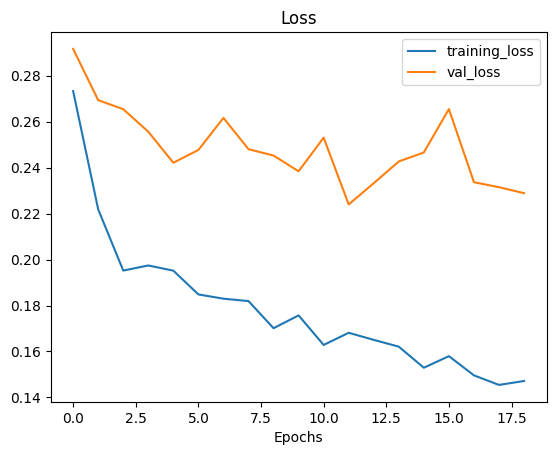

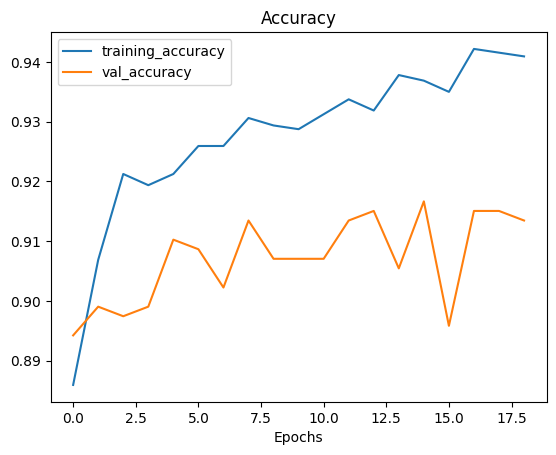

In [ ]:
plot_loss_curves(history2)

In [ ]:
model_5.evaluate(test_data_aug)

20/20 [==============================] - 14s 671ms/step - loss: 0.4641 - accuracy: 0.8157


[0.4640650749206543, 0.8157051205635071]

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing# 1. Create base model with tf.keras.application
base_model = tf.keras.applications.vgg16.VGG16(include_top=False)

# 2. Freeze the base model
base_model.trainable = False

# 3. Create inputs into the base model
inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")

# 4 . Rescaling the images
x = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)(inputs)

# 4. Pass the inputs to the base model
x = base_model(inputs)

# 5. Average pool the outputs of the base model
x = tf.keras.layers.GlobalAveragePooling2D(name="GAPL")(x)

# 6. Create the output activation layer
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output_layer")(x)

# 7. Combine the inputs with the outputs into the model
model_6 = tf.keras.Model(inputs, outputs)

In [ ]:
# Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Fit the model
hist_6 =  model_6.fit(train_data_aug,
                     epochs=5,
                     steps_per_epoch=len(train_data_aug),
                     validation_data=test_data_aug,
                     validation_steps=int(0.25 * len(test_data_aug)))

Epoch 1/5
163/163 [==============================] - 138s 772ms/step - loss: 0.5065 - accuracy: 0.7448 - val_loss: 0.6074 - val_accuracy: 0.6000
Epoch 2/5
163/163 [==============================] - 121s 744ms/step - loss: 0.4185 - accuracy: 0.7820 - val_loss: 0.5640 - val_accuracy: 0.6562
Epoch 3/5
163/163 [==============================] - 123s 756ms/step - loss: 0.3686 - accuracy: 0.8340 - val_loss: 0.4417 - val_accuracy: 0.7500
Epoch 4/5
163/163 [==============================] - 121s 742ms/step - loss: 0.3379 - accuracy: 0.8495 - val_loss: 0.3837 - val_accuracy: 0.8062
Epoch 5/5
163/163 [==============================] - 122s 749ms/step - loss: 0.3177 - accuracy: 0.8646 - val_loss: 0.4671 - val_accuracy: 0.7375


# With MoblieNetV2

In [ ]:
mobilenet_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top = False,
#     input_shape = (224,224,3)
)

for layer in mobilenet_model.layers:
    layer.trainable=False
    
x = mobilenet_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model3 = tf.keras.Model(inputs=mobilenet_model.input, outputs=predictions)

# to avoid overfitting
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=8)

# Compiling the model
model3.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])
history3 = model3.fit(train_data_aug,epochs=30, 
                    validation_data=test_data_aug,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

NameError: ignored

# With Xception


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
# Create a base model with tf.keras application
base_model = tf.keras.applications.xception.Xception(input_shape = (224,224,3), include_top = False,weights='imagenet');
 # Freezethe base model
base_model.trainable = False;

#Create inputs to base_model
inputs = tf.keras.layers.Input(shape=(224,224,3),name = "inputlayer")
# x = data_augmentation(inputs)
# x = base_model(x,training = False)
x = base_model(inputs)
x = layers.GlobalAveragePooling2D(name = "GAPL")(x)
outputs = layers.Dense(1,activation="sigmoid",name="outputlayer")(x)
model_8 = keras.Model(inputs,outputs);
model_8.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

hist_8 =  model_8.fit(train_data,
                     epochs=20,
                     steps_per_epoch=len(train_data),
                     validation_data=test_data,
                     validation_steps=int(0.25 * len(test_data)))

Epoch 1/20
163/163 [==============================] - 37s 204ms/step - loss: 0.5526 - accuracy: 0.8593 - val_loss: 1.0271 - val_accuracy: 0.7625
Epoch 2/20
163/163 [==============================] - 33s 192ms/step - loss: 0.2433 - accuracy: 0.9216 - val_loss: 0.8530 - val_accuracy: 0.7937
Epoch 3/20
163/163 [==============================] - 34s 200ms/step - loss: 0.2227 - accuracy: 0.9294 - val_loss: 0.9011 - val_accuracy: 0.7750
Epoch 4/20
163/163 [==============================] - 33s 194ms/step - loss: 0.1982 - accuracy: 0.9377 - val_loss: 1.3865 - val_accuracy: 0.7250
Epoch 5/20
163/163 [==============================] - 33s 188ms/step - loss: 0.1805 - accuracy: 0.9415 - val_loss: 0.9783 - val_accuracy: 0.7750
Epoch 6/20
163/163 [==============================] - 33s 194ms/step - loss: 0.1802 - accuracy: 0.9411 - val_loss: 1.1972 - val_accuracy: 0.7125
Epoch 7/20
163/163 [==============================] - 32s 189ms/step - loss: 0.1563 - accuracy: 0.9486 - val_loss: 0.9366 - val_ac

In [ ]:
# Creating a Model checkpoint callback
checkpoint_path = "model_2_weights/checkpoint.ckpt"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True,
                                                         save_best_onlly=False,
                                                         save_freq="epoch",
                                                         verbose=1)

In [ ]:

import datetime

def create_tensorboard_callback(dir_name, experiment_name):
  """
  Creates a TensorBoard callback instand to store log files.

  Stores log files with the filepath:
    "dir_name/experiment_name/current_datetime/"

  Args:
    dir_name: target directory to store TensorBoard log files
    experiment_name: name of experiment directory (e.g. efficientnet_model_1)
  """
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

In [ ]:
# Fit the model having checkpoints every epoch
initial_epochs = 5
hist_2 = model_2.fit(train_data_aug,
                     epochs=initial_epochs,
                     validation_data=test_data_aug,
                     validation_steps=int(0.25 * len(test_data_aug)),
                     callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                            experiment_name="model_2_Efficient_Net"),
                                checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/model_2_Efficient_Net/20230327-160116
Epoch 1/5
163/163 [==============================] - ETA: 0s - loss: 0.5094 - accuracy: 0.7446
Epoch 1: saving model to model_2_weights/checkpoint.ckpt
163/163 [==============================] - 120s 728ms/step - loss: 0.5094 - accuracy: 0.7446 - val_loss: 0.6279 - val_accuracy: 0.6187
Epoch 2/5
163/163 [==============================] - ETA: 0s - loss: 0.4121 - accuracy: 0.7914
Epoch 2: saving model to model_2_weights/checkpoint.ckpt
163/163 [==============================] - 117s 720ms/step - loss: 0.4121 - accuracy: 0.7914 - val_loss: 0.5347 - val_accuracy: 0.6750
Epoch 3/5
163/163 [==============================] - ETA: 0s - loss: 0.3693 - accuracy: 0.8288
Epoch 3: saving model to model_2_weights/checkpoint.ckpt
163/163 [==============================] - 118s 721ms/step - loss: 0.3693 - accuracy: 0.8288 - val_loss: 0.5128 - val_accuracy: 0.7250
Epoch 4/5
163/163 [==============================]

In [ ]:
model_3.evaluate(test_data)

20/20 [==============================] - 6s 251ms/step - loss: 9.6406 - accuracy: 0.3750


[9.640592575073242, 0.375]

# Loading in checkpointed Weights

In [ ]:
model_2.load_weights(checkpoint_path)

In [ ]:
# Evaluate model_2
loaded_weights_model_results = model_2.evaluate(test_data)

20/20 [==============================] - 5s 165ms/step - loss: 9.6406 - accuracy: 0.3750


In [ ]:
# Layers in the model_2
model_2.layers

# Fine-Tuning
Note :Fine-tuning works best after training a feature extraction model for a few epochs with larger amounts of custom data.

In [ ]:
# Saving these 3 models
model.save('vgg19.h5')
model2.save('resnet50v2.h5')
model3.save('mobilenetv2.h5')

In [ ]:
resnet_model.trainable = True
vgg_model.trainable = True
mobilenet_model.trainable = True

## vggmodel

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(vgg_model.layers))

# Fine tune from this layer onwards
fine_tune_at = 100

# Freezing the layers
for layer in  vgg_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  22


In [ ]:
# Compiling the model
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
fine_tune_epochs = 10
epochs_on_the_model = 30
total_epochs = fine_tune_epochs+ epochs_on_the_model

history_finetune = model.fit(train_data_aug,
                             epochs=total_epochs,
                             validation_data=test_data_aug,
                             steps_per_epoch=100,
                             callbacks=[early_stopping,lr],
                             batch_size=32)

Epoch 1/40
100/100 [==============================] - 88s 865ms/step - loss: 0.5629 - accuracy: 0.7441 - val_loss: 0.6710 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 2/40
100/100 [==============================] - 85s 847ms/step - loss: 0.5649 - accuracy: 0.7469 - val_loss: 0.6916 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 3/40
100/100 [==============================] - ETA: 0s - loss: 0.5601 - accuracy: 0.7478

KeyboardInterrupt: ignored

In [ ]:
# Evaluating the model on train and test
score = model.evaluate(train_data_aug)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model.evaluate(test_data_aug)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

## resnetmodel

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(resnet_model.layers))

# Fine tune from this layer onwards
fine_tune_at = 100


# Freezing the layers
for layer in  resnet_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  190


In [ ]:
print(len(model2.trainable_variables))

86


In [ ]:
# Compiling the model
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
fine_tune_epochs = 10
epochs_on_the_model = 30
total_epochs = fine_tune_epochs+ epochs_on_the_model

history_finetune1 = model2.fit(train_data_aug,
                             epochs=total_epochs,
                             validation_data=test_data_aug,
                             steps_per_epoch=100,
                            #  callbacks=[early_stopping,lr],
                             batch_size=32)

Epoch 1/40
100/100 [==============================] - 104s 890ms/step - loss: 0.1559 - accuracy: 0.9469 - val_loss: 149.7348 - val_accuracy: 0.6250
Epoch 2/40
100/100 [==============================] - 84s 840ms/step - loss: 0.1415 - accuracy: 0.9469 - val_loss: 0.4916 - val_accuracy: 0.9407
Epoch 3/40
100/100 [==============================] - 86s 857ms/step - loss: 0.1415 - accuracy: 0.9494 - val_loss: 0.3527 - val_accuracy: 0.9167
Epoch 4/40
100/100 [==============================] - 88s 883ms/step - loss: 0.1273 - accuracy: 0.9531 - val_loss: 0.2333 - val_accuracy: 0.9167
Epoch 5/40
100/100 [==============================] - 84s 838ms/step - loss: 0.1219 - accuracy: 0.9569 - val_loss: 0.2481 - val_accuracy: 0.9343
Epoch 6/40
100/100 [==============================] - 84s 837ms/step - loss: 0.1207 - accuracy: 0.9556 - val_loss: 0.3491 - val_accuracy: 0.9327
Epoch 7/40
100/100 [==============================] - 84s 836ms/step - loss: 0.1174 - accuracy: 0.9550 - val_loss: 0.1888 - val

In [ ]:




# Evaluating the model on train and test
score = model2.evaluate(train_data_aug)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model2.evaluate(test_data_aug)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 118s 723ms/step - loss: 0.0929 - accuracy: 0.9691
Train Loss:  0.09285736083984375
Train Accuracy:  0.9691334366798401
20/20 [==============================] - 7s 317ms/step - loss: 0.2026 - accuracy: 0.9439

Test loss:  0.20261284708976746
Test Accuracy:  0.9439102411270142


## mobilenetmodel

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(mobilenet_model.layers))

# Fine tune from this layer onwards
fine_tune_at = 100

# Freezing the layers
for layer in  mobilenet_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [ ]:
# Compiling the model
model3.compile(loss='binary_crossentropy',optimizer='RMSprop',metrics=['accuracy'])

In [ ]:
fine_tune_epochs = 10
epochs_on_the_model = 30
total_epochs = fine_tune_epochs+ epochs_on_the_model

history_finetune2 = model3.fit(train_data_aug,
                             epochs=total_epochs,
                             validation_data=test_data_aug,
                             steps_per_epoch=100,
                             callbacks=[early_stopping,lr],
                             batch_size=32)

Epoch 1/40
100/100 [==============================] - 87s 780ms/step - loss: 0.1524 - accuracy: 0.9403 - val_loss: 8.2800 - val_accuracy: 0.6298 - lr: 0.0010
Epoch 2/40
100/100 [==============================] - 77s 773ms/step - loss: 0.1338 - accuracy: 0.9475 - val_loss: 6.2864 - val_accuracy: 0.6266 - lr: 0.0010
Epoch 3/40
100/100 [==============================] - 79s 792ms/step - loss: 0.1360 - accuracy: 0.9472 - val_loss: 5.9694 - val_accuracy: 0.6346 - lr: 0.0010
Epoch 4/40
100/100 [==============================] - 80s 797ms/step - loss: 0.1297 - accuracy: 0.9553 - val_loss: 7.2018 - val_accuracy: 0.6330 - lr: 0.0010
Epoch 5/40
100/100 [==============================] - 79s 786ms/step - loss: 0.1196 - accuracy: 0.9572 - val_loss: 9.9516 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 6/40
100/100 [==============================] - 78s 783ms/step - loss: 0.1154 - accuracy: 0.9547 - val_loss: 6.7529 - val_accuracy: 0.6314 - lr: 0.0010
Epoch 7/40
100/100 [==============================] 

In [ ]:
# Evaluating the model on train and test
score = model3.evaluate(train_data_aug)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model3.evaluate(test_data_aug)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 117s 720ms/step - loss: 0.3047 - accuracy: 0.9327
Train Loss:  0.3047361969947815
Train Accuracy:  0.9327070713043213
20/20 [==============================] - 6s 284ms/step - loss: 2.0851 - accuracy: 0.7660

Test loss:  2.085122585296631
Test Accuracy:  0.7660256624221802


In [ ]:
model2.save('tuned_resnet.h5')
model3.save('tuned_mobilenet.h5')

In [ ]:
# Loading the saved version of Tuned-ResNet50V2
final_model = tf.keras.models.load_model('tuned_resnet.h5')

In [ ]:
y_pred = final_model.predict(test_data_aug)

20/20 [==============================] - 7s 309ms/step


In [ ]:
final_model.evaluate(test_data_aug)


20/20 [==============================] - 8s 343ms/step - loss: 0.2026 - accuracy: 0.9439


[0.20261284708976746, 0.9439102411270142]

In [ ]:
from google.colab import files
files.download('tuned_resnet.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_pred = final_model.predictproba(test_data_aug)

AttributeError: ignored

In [ ]:
final_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            